# 13 · Day 2 종합 캡스톤 — 딥러닝 전처리 파이프라인 (커스텀 커널 + interop)

> **CuPy 2일 집중 코스 — Day 2 / 단원 9 · 마무리 통합 실습 (약 60분)**

Day 2의 핵심을 하나의 **DL 전처리 파이프라인**으로 통합합니다: GPU에서 배치 신호를 표준화→**커스텀 커널** 비선형→
특징 추출(리덕션)→ **무복사로 PyTorch 모델 입력**. 그리고 v0→v1(fuse·메모리)→v2(스트림)로 최적화합니다.

## 무엇을 통합하나
| 단계 | 기법 | 출처 |
|------|------|------|
| 표준화·특징 | ndarray·리덕션 | 02·07 |
| 비선형 커스텀 커널 | `ElementwiseKernel`/`@cupy.fuse` | 07 |
| v1 최적화 | fuse·out=·전송↓ | 05·07 |
| v2 최적화 | 스트림 청크 오버랩 | 06 |
| 모델 입력 | DLPack 무복사 | 12 |

## 목표
- 커스텀 커널을 포함한 전처리를 **end-to-end GPU**로 구성한다.
- v0→v1→v2 단계 최적화 + 정확성 검증 + 무복사 모델 연동.

### 이 캡스톤이 엮는 노트북들

이 노트북은 지금까지 배운 8개 노트북의 기법을 **하나의 실행
경로**에 순서대로 꿰어 넣습니다. 표를 코드 흐름 순서로 다시 풀면 다음과 같습니다.

1. **`02_ndarray_core`** — `standardize`의 `axis=1, keepdims=True` 브로드캐스팅, `get_array_module`로
   device-비종속 코드 작성.
2. **`07_cupy_kernels`** — Stage 2의 `ElementwiseKernel`을 손으로 작성해 비선형 활성화를 단일 커널로 융합.
3. **`03_numpy_routines`** — `@cupy.fuse`로 같은 목적(융합)을 **자동으로** 달성하는 v1.
4. **`05_memory_profiling`** — 중간 배열을 줄이고 파이프라인을 GPU에 머무르게 하는 메모리 최적화 사고방식.
5. **`06_streams_async`** — v2의 스트림 청크 오버랩, 그리고 도전 과제의 pinned 비동기 전송·CUDA Graph.
6. **`10_cccl`** / **`11_rawkernel`** — 도전 과제에서 `ReductionKernel`·`RawKernel`로 한 단계 더 낮은
   레벨까지 내려가 봅니다.
7. **`12_interop_frameworks`** — 마지막 단계에서 DLPack으로 PyTorch에 무복사 전달.

### 왜 v0→v1→v2 순서로 최적화하는가

이 진행은 **Day 1 마무리**였던 `day1_capstone`과 같은 순서(v0 naive → v1 fuse/메모리 →
v2 스트림)를 다시 사용합니다 — 이 코스 전체에서 "최적화는 임의의 트릭이 아니라 반복 가능한
3단계 절차"라는 메시지를 재확인합니다. 다만 이번엔 FFT·PCA 대신
**커스텀 CUDA 커널**과 **프레임워크 상호운용**이 그 자리를 채웁니다.

- **v0(naive)**: 표준화 → (손으로 작성한) `ElementwiseKernel` 비선형 → 평균 리덕션을 순서대로 호출.
  이미 비선형 단계 자체는 단일 커널이지만, 표준화·리덕션은 여전히 여러 개의 개별 CuPy 호출로
  이뤄져 있어 "완전히 손대지 않은 진짜 naive"는 아닙니다.
- **v1(fuse)**: 손으로 쓴 CUDA C 커널(`ElementwiseKernel`) 대신 순수 파이썬 함수에 `@cp.fuse()`를
  붙여 **같은 목적지(단일 커널 융합)에 다른 경로로 도달**합니다. 즉 v0→v1은 "느린 것 → 빠른 것"이
  아니라 "수동 커널 작성 vs 자동 커널 생성" 두 방식을 대비시키는 데 더 가깝습니다.
- **v2(스트림)**: 이미 GPU에 있는 배치를 청크로 나눠 여러 스트림에 흩뿌려 **커널 간 동시 실행**을
  유도합니다. 데이터가 이미 device에 있으므로 이번 v2는 "전송 오버랩"이 아니라 "연산 오버랩"이며,
  진짜 전송 오버랩은 뒤쪽 도전 과제 3(pinned+스트림)에서 별도로 다룹니다.


In [1]:
import numpy as np, cupy as cp
import matplotlib.pyplot as plt
from course_utils import print_env, bench, gpu_ms, cpu_ms, print_bench, compare, allclose
print_env()
try:
    import torch; HAS_TORCH = torch.cuda.is_available()
except Exception: HAS_TORCH = False
B, N = 512, 50_000

=== Environment ===
numpy: 2.3.5
cupy : 14.1.1
device: 0 - NVIDIA A100-SXM4-80GB (compute capability 8.0)
VRAM  : 79.25 GB


## Stage 0 — 데이터 생성 (GPU)

(B, N) 잡음 신호 배치. 검증용 host 사본도 둡니다.

배치 크기 `B`(신호 개수)와 길이 `N`(신호 하나의 샘플 수)은 이후 모든 단계의 텐서 shape를 결정합니다.
아래 코드 셀은 (다소 이례적으로) `B, N`을 두 번 재정의하는데, 첫 셀(맨 위 import 셀)에서 이미
`B, N = 512, 50_000`을 설정해 두었지만 이 노트북에서 실제로 실행에 쓰이는 값은 여기서 다시 덮어쓴
`B, N = 1000, 5000`입니다. 실전 파이프라인에서도 각 단계가 자기 앞단의 설정을 그대로 신뢰하지
않고 필요한 shape를 스스로 확인·재설정하는 방어적 습관이 흔합니다 — 다만 노트북을 읽을 때는
"어느 시점의 B, N이 실제로 유효한가"를 헷갈리지 않도록 주의하세요.

데이터 생성 자체는 **host(NumPy)에서 만든 뒤 `cp.asarray`로 한 번만 전송**하는 패턴입니다.
`cp.random`으로 GPU에서 직접 생성할 수도 있지만(그 편이 전송 비용이 없어 더 빠릅니다), 여기서는
`X_np`를 CPU 기준값(reference)으로 그대로 남겨 두어야 하므로 host에서 생성 후 전송하는 편이
검증 관점에서 더 간단합니다. `B*N = 5,000,000`개 float32 원소이므로 배열 하나의 크기는 약 19MB —
PCIe 전송 자체는 `00_intro_env`에서 본 대역폭(수십 GB/s)상 1ms 안팎이면 끝나는 크기입니다.

시각화에서 쓰는 `X_cp[0].get()`은 `cp.asnumpy`와 동일하게 device→host PCIe 복사를 일으킵니다.
플롯 한 번을 위한 이 정도 전송은 문제가 아니지만("결과 확인을 위한 마지막 한 번"), 이후 단계들에서는
이런 `.get()`/`asnumpy` 호출을 **반복문 밖, 정말 필요한 순간에만** 쓰는 것이 v1의 핵심 규칙 중 하나임을
기억해 두세요.


X_cp shape: (1000, 5000)


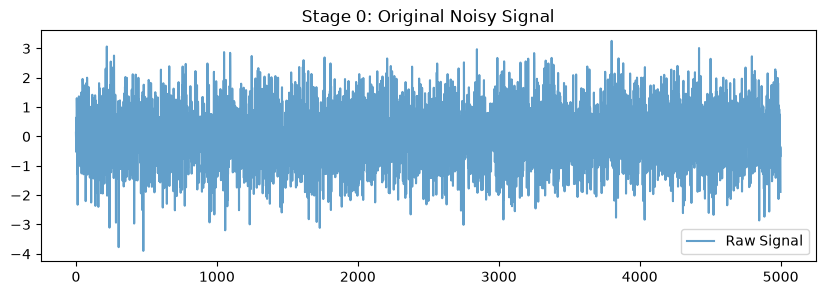

In [3]:

# B: 배치 크기 (데이터 개수), N: 신호 길이
B, N = 1000, 5000 

# 1. 데이터 생성 (GPU)
B, N = 1000, 5000 
# 1. Host (CPU): 컴퓨터 RAM에 더미 노이즈 신호를 생성합니다.
rng = np.random.default_rng(0)
X_np = rng.standard_normal((B, N)).astype(np.float32)

# 2. PCIe 통신: CPU 메모리의 데이터를 GPU 메모리로 복사합니다.
X_cp = cp.asarray(X_np)

print('X_cp shape:', X_cp.shape)

# [시각화] 원본 신호 (첫 번째 샘플)
plt.figure(figsize=(10, 3))
# GPU(CuPy) 데이터를 Matplotlib으로 그리려면 .get()으로 CPU로 가져와야 합니다.
plt.plot(X_cp[0].get(), alpha=0.7, label='Raw Signal')
plt.title('Stage 0: Original Noisy Signal')
plt.legend()
plt.show()

## Stage 1 — 행별 표준화 (TODO)

각 신호(행)를 z-score 표준화 (02, 브로드캐스팅, 장치 비종속).
데이터의 평균을 0, 분산을 1로 맞추는 z-score 표준화 작업을 진행합니다.

### 조금 더 구체적으로

수식으로 쓰면 각 행 $i$에 대해 $z_i = (x_i - \mu_i) / (\sigma_i + \epsilon)$ 입니다. 여기서 평균
$\mu_i$·표준편차 $\sigma_i$는 **행(axis=1) 단위**로 따로 계산됩니다 — `mean(axis=1, keepdims=True)`처럼
`keepdims=True`를 유지해야 `(B, 1)` shape가 되어 `(B, N)` 원본과 **브로드캐스팅**으로 나눗셈이
자연스럽게 맞물립니다(`02_ndarray_core`). `keepdims`를 빼면 `(B,)`가 되어 브로드캐스팅 축이
어긋나 에러가 나거나 엉뚱한 결과가 나올 수 있습니다.

`+1e-6`은 이 노트북 전체에서 반복되는 안전장치입니다: 만약 어떤 행이 상수(분산이 0)라면 나눗셈이
`0/0`이 되어 `nan`이 퍼질 수 있는데, 아주 작은 값을 분모에 더해 두면 이런 경계 조건에서도 값이
발산하지 않고 안전하게 처리됩니다. `00_intro_env` 연습문제의 `feature_gpu`에서 쓴 `+1e-8`과
같은 목적의 코드이며, 이 함수 자체도 `day1_capstone`의 Stage 1 `standardize`와 **완전히 동일한
구현**입니다 — Day 1/Day 2 두 캡스톤이 같은 전처리 골격을 공유한다는 뜻입니다.

CuPy는 함수 하나로 CPU(NumPy)와 GPU(CuPy) 양쪽에서 돌아가는 코드를 쓸 수 있게 해주는데, 그 열쇠가
바로 `cp.get_array_module(X)`입니다 — 입력이 NumPy 배열이면 `np`를, CuPy 배열이면 `cp`를 돌려주는
디스패치 함수로, `02`에서 이미 다룬 "장치 비종속(device-agnostic) 코드" 패턴입니다. 아래 해답에서
바로 이 패턴을 사용합니다.


In [4]:
def standardize_ref(X):
    mu = np.mean(X, axis=1, keepdims=True)
    sd = np.std(X, axis=1, keepdims=True)+1e-6
    return (X-mu)/sd

def standardize(X):
    # TODO: xp 선택 후 (X-행평균)/(행std+1e-6)
    # 1. X가 NumPy 배열이면 np를, CuPy 배열이면 cp를 반환하여 환경에 맞춥니다.
    # 2. 각 신호(행, axis=1)별로 평균과 표준편차를 계산합니다.
    # 3. 0으로 나누는 오류를 방지하기 위해 아주 작은 값(1e-6)을 더해줍니다.
    # 4. 표준화 적용하여 리턴합니다.
    raise NotImplementedError

# 데이터에 표준화 적용
z_cp = standardize(X_cp)

# 📊 [시각화] 표준화된 신호
plt.figure(figsize=(10, 3))
z_sample = z_cp[0].get()
plt.plot(z_sample, color='orange', alpha=0.7, label='Standardized Signal')
plt.title(f'Stage 1: Standardized (Mean: {z_sample.mean():.2f}, Std: {z_sample.std():.2f})')
# z-score이므로 Y축을 -4 ~ 4로 고정하여 변화를 명확히 봅니다.
plt.ylim(-4, 4)
plt.legend()
plt.show()

NotImplementedError: 

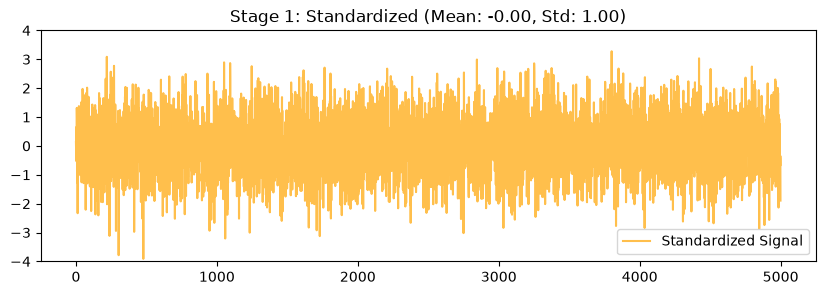

In [6]:
def standardize_ref(X):
    mu = np.mean(X, axis=1, keepdims=True)
    sd = np.std(X, axis=1, keepdims=True)+1e-6
    return (X-mu)/sd

def standardize(X):
    xp = cp.get_array_module(X)
    mu = xp.mean(X, axis=1, keepdims=True); sd = xp.std(X, axis=1, keepdims=True)+1e-6
    return (X-mu)/sd

# 데이터에 표준화 적용
z_cp = standardize(X_cp)

# 📊 [시각화] 표준화된 신호
plt.figure(figsize=(10, 3))
z_sample = z_cp[0].get()
plt.plot(z_sample, color='orange', alpha=0.7, label='Standardized Signal')
plt.title(f'Stage 1: Standardized (Mean: {z_sample.mean():.2f}, Std: {z_sample.std():.2f})')
# z-score이므로 Y축을 -4 ~ 4로 고정하여 변화를 명확히 봅니다.
plt.ylim(-4, 4)
plt.legend()
plt.show()

`xp = cp.get_array_module(X)` 한 줄 덕분에 이 함수는 `X`가 `np.ndarray`든 `cupy.ndarray`든 분기문
없이 그대로 동작합니다 — 아래 Stage 3에서 `features_v0(X_np)`(CPU)와 `features_v0(X_cp)`(GPU)를
**같은 함수**로 호출해 결과를 비교할 수 있는 이유가 바로 이것입니다.

<details><summary>💡 해답 보기</summary>

```python
def standardize(X):
    xp = cp.get_array_module(X)
    mu = xp.mean(X, axis=1, keepdims=True); sd = xp.std(X, axis=1, keepdims=True)+1e-6
    return (X-mu)/sd
```
</details>

## Stage 2 — 비선형 커스텀 커널 (TODO)

활성화 `g = tanh(z)·exp(-z²)` 를 **커스텀 커널**로(07). 먼저 `ElementwiseKernel`로 작성합니다.

이제 표준화된 데이터에 비선형 활성화 함수 `g = tanh(z)·exp(-z²)` 를 적용합니다.
CuPy 내장 함수들을 그냥 조합해도 되지만, 커스텀 커널(ElementwiseKernel)을 직접 작성하면 성능을 한계까지 끌어올릴 수 있습니다.

- 비선형 활성화 함수는 왜 필요할까요?
    * 단순한 선형 연산(더하기, 곱하기)만으로는 노이즈 속에서 유의미한 패턴을 걸러내기 어렵습니다.
    * 비선형 함수를 사용하면 특정 조건의 데이터만 살리고 나머지는 죽이는 식별력을 가질 수 있습니다.
    * 여기서 사용할 함수는 0에 가까운 유효 신호는 강조하고, 극단적으로 크거나 작은 노이즈(이상치)는 0으로 억제하는 역할을 합니다.

### 조금 더 구체적으로: `ElementwiseKernel`은 무엇을 대신해주나

`cp.ElementwiseKernel('float32 z', 'float32 g', 'g = tanhf(z) * expf(-z*z);', 'nl_act')`는
`07_cupy_kernels`에서 다룬 세 CUDA C 함수(`tanhf`, `expf`, 곱셈)를 **원소 하나당 딱 한 번의 커널
실행**으로 묶습니다. 입력 `z`를 한 번 읽고, 결과 `g`를 한 번 쓰는 것으로 끝입니다.

같은 결과를 `cp.tanh(z) * cp.exp(-z*z)`처럼 CuPy 내장 함수 조합으로 얻으면, 내부적으로
`tanh(z)`, `-z*z`, `exp(...)`, 최종 곱셈까지 **여러 개의 별도 커널**이 순서대로 실행되고, 그때마다
`(B, N)` 크기의 **중간 배열**이 새로 할당·기록·재로드됩니다. `B=1000, N=5000`이면 배열 하나가
약 19MB이므로, 중간 배열이 3~4개 생기면 그만큼 추가 메모리 트래픽이 발생합니다 —
`05_memory_profiling`에서 말하는 "메모리 병목(memory-bound)" 연산이 바로 이런 형태입니다.
직접 커널을 쓰면 이 왕복이 통째로 사라집니다.

함수의 모양 자체도 뜯어볼 가치가 있습니다. $z=0$ 근방에서는 $\tanh(z) \approx z$이고
$\exp(-z^2) \approx 1$이라 $g(z) \approx z$ — 즉 원점 부근에서는 거의 항등함수처럼 작동해 약한
신호를 그대로 통과시킵니다. 반대로 $|z|$가 커지면 $\exp(-z^2)$ 항이 급격히 0에 가까워집니다
(예: $z=3$이면 $\exp(-9) \approx 1.2\times10^{-4}$) — 즉 표준편차 대비 3배 이상 벗어난 극단값은
사실상 완전히 억제됩니다. 그 사이 구간(대략 $|z|\approx 0.5\sim1$)에서 곡선이 봉우리를 이루며,
오른쪽 그래프에서 확인하는 "노이즈는 죽고 중간 신호만 살아남는" 모양이 이렇게 만들어집니다.


In [7]:
# 검증용 순수 CuPy 참조
def nl_ref(z) :
    return cp.tanh(z)*cp.exp(-z*z)

# TODO: nl = cp.ElementwiseKernel('float32 z','float32 g',
#            'g = tanhf(z) * expf(-z*z);', 'nl_act')
# (또는 @cp.fuse 버전을 v1에서 사용)

# 데이터에 비선형 활성화 적용
g_cp = nl(z_cp)

# 📊 [시각화] 커널의 형태와 활성화된 신호 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# 왼쪽: 커널의 이론적 형태 (어떤 신호를 살리고 죽이는지 확인)
z_range = np.linspace(-5, 5, 200)
axes[0].plot(z_range, np.tanh(z_range) * np.exp(-z_range**2), 'r--')
axes[0].set_title('Kernel Shape: tanh(z) * exp(-z²)')
axes[0].grid(True)

# 오른쪽: 커널을 통과하여 노이즈가 억제된 실제 신호
axes[1].plot(g_cp[0].get(), color='purple', alpha=0.7)
axes[1].set_title('Stage 2: Activated Signal (Noise Suppressed)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

NameError: name 'nl' is not defined

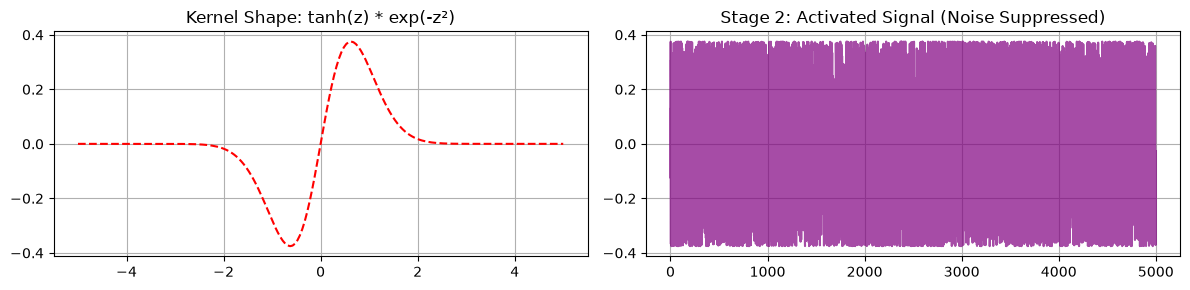

In [8]:
# 검증용 순수 CuPy 참조
def nl_ref(z) :
    return cp.tanh(z)*cp.exp(-z*z)

nl = cp.ElementwiseKernel('float32 z','float32 g',
                          'g = tanhf(z) * expf(-z*z);', 'nl_act')
# 검증용 순수 CuPy 참조
def nl_ref(z): return cp.tanh(z)*cp.exp(-z*z)

# 데이터에 비선형 활성화 적용
g_cp = nl(z_cp)

# 📊 [시각화] 커널의 형태와 활성화된 신호 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# 왼쪽: 커널의 이론적 형태 (어떤 신호를 살리고 죽이는지 확인)
z_range = np.linspace(-5, 5, 200)
axes[0].plot(z_range, np.tanh(z_range) * np.exp(-z_range**2), 'r--')
axes[0].set_title('Kernel Shape: tanh(z) * exp(-z²)')
axes[0].grid(True)

# 오른쪽: 커널을 통과하여 노이즈가 억제된 실제 신호
axes[1].plot(g_cp[0].get(), color='purple', alpha=0.7)
axes[1].set_title('Stage 2: Activated Signal (Noise Suppressed)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

`nl_ref`는 순수 CuPy 연산(`cp.tanh`·`cp.exp`)만으로 다시 구현한 같은 함수입니다 — 손으로 쓴
CUDA C 커널 `nl`이 올바르게 동작하는지 **참조 구현과 비교해 검증**할 때 씁니다. 이렇게 "저수준
구현 vs 고수준 참조 구현을 나란히 두고 `allclose`로 맞춰본다"는 패턴은 이후 v1(`@cp.fuse`)에서도,
도전 과제의 `ReductionKernel`/`RawKernel`에서도 반복됩니다.

<details><summary>💡 해답 보기</summary>

```python
nl = cp.ElementwiseKernel('float32 z','float32 g',
                          'g = tanhf(z) * expf(-z*z);', 'nl_act')
# 검증용 순수 CuPy 참조
def nl_ref(z): return cp.tanh(z)*cp.exp(-z*z)
```
</details>

## Stage 3 — 특징 추출 & v0 조립

활성화 결과의 **행별 평균**을 특징으로 합니다(간단). 전체 파이프라인을 조립하고 CPU/GPU 검증.

### 조금 더 구체적으로

`g.mean(axis=1)`은 `(B, N)` 배열을 `(B,)` 벡터로 줄이는 **리덕션(reduction)** 연산입니다.
내부적으로 CuPy는 이런 축소 연산을 위해 (사용자가 직접 보지 않아도) 병렬 트리 리덕션 커널을
호출합니다 — 뒤에서 직접 작성하는 `cp.ReductionKernel`(도전 과제 1)이 바로 이 내장 리덕션을
사용자 정의 연산으로 일반화한 것입니다(`07`).

`features_v0`는 Stage 1의 `standardize`와 Stage 2에서 만든 `nl`(GPU) 또는 그 NumPy 등가식(CPU)을
그대로 이어 붙인 것으로, **이 노트북 전체 파이프라인의 "정답 기준(reference)"** 역할을 합니다 —
이후 v1·v2·도전 과제의 모든 대안 구현은 결국 `features_v0`와 값이 같아야 합니다.

검증에는 `np.allclose(ref, out, rtol=1e-3, atol=1e-3)`처럼 **NumPy의 원본 함수**를 직접 씁니다.
이 노트북 앞부분에서 import한 `course_utils.allclose`(내부에서 `assert_allclose` + 통과 메시지
출력을 자동화)와 기능은 같고, 여기서는 단순히 불린 결과만 확인하는 얕은 버전이라 보면 됩니다 —
뒤쪽 v1·v2 검증부터는 `course_utils.allclose`를 사용해 통과 여부를 자동으로 assert합니다.
`rtol=atol=1e-3`처럼 `00_intro_env`의 단순 연산(`1e-5`)보다 느슨한 허용오차를 쓰는 이유는, 표준화
→ 비선형 → 리덕션으로 이어지는 여러 단계에서 CPU와 GPU의 부동소수점 연산 순서 차이가 누적되기
때문입니다 — 연산이 깊어질수록 허용오차를 넉넉히 잡아야 한다는 `00`의 원칙이 여기서도 적용됩니다.


In [ ]:
def features_v0(X):
    z = standardize(X)
    g = nl(z) if cp.get_array_module(X) is cp else (np.tanh(z)*np.exp(-z*z))
    return g.mean(axis=1)        # (B,) 특징

# GPU vs CPU 연산 결과 검증
ref = features_v0(X_np)
out = cp.asnumpy(features_v0(X_cp))
print(f"검증 통과 여부: {np.allclose(ref, out, rtol=1e-3, atol=1e-3)}")

# 📊 [시각화] 최종 추출된 특징(Feature)들의 분포 확인
plt.figure(figsize=(6, 4))
plt.hist(out, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title('Stage 3: Distribution of Extracted Features (B=1000)')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

## 최적화 v1 — @cupy.fuse + 전송 최소화

비선형을 **융합 커널**로 바꿔 중간배열을 줄이고, 끝까지 GPU에 머무릅니다(05·07).

### 조금 더 구체적으로: 두 가지 융합 경로

Stage 2에서는 `ElementwiseKernel`로 CUDA C 코드를 **직접** 작성해 비선형을 하나의 커널로 묶었습니다.
v1의 `@cp.fuse()`는 **같은 목표(여러 원소별 연산을 한 커널로 압축)를 자동으로** 달성하는 다른
경로입니다: 데코레이터가 붙은 함수를 처음 호출할 때 CuPy가 그 안의 연산 그래프(`cp.tanh`, `cp.exp`,
곱셈 등)를 추적(trace)해 등가의 단일 커널을 즉석 생성·캐시합니다(`03_numpy_routines`에서 소개한
`@cupy.fuse`, `07`에서 `ElementwiseKernel`/`ReductionKernel`과의 관계를 정리). 즉 v0→v1의 차이는
"느린 구현 → 빠른 구현"이 아니라, **손으로 커널을 짜는 방식과 파이썬 코드에서 자동으로 커널을
생성하는 방식**을 나란히 비교해보는 데 있습니다 — 실무에서는 유지보수 편의성 때문에 후자를 먼저
시도하고, 극한의 튜닝이 필요할 때만 전자로 내려가는 경우가 많습니다.

한 가지 주의할 점: `@cp.fuse`는 그 안에 적힌 **원소별(elementwise) 연산 체인만** 하나로 묶습니다.
`nl_fused(z).mean(axis=1)`처럼 뒤에 붙는 `.mean()` 리덕션은 별도의 커널로 남습니다 — 즉 v1은
"비선형 계산 1개 커널 + 평균 리덕션 1개 커널", 총 2개의 커널 실행입니다. 요소별 계산과 리덕션까지
**하나의 커널로 완전히 합치는 방법**은 도전 과제 1의 `ReductionKernel`에서 다룹니다.

"전송 최소화"를 위해 `features_v1(X)`가 표준화부터 평균까지 **모든 중간 결과를
GPU 배열로만** 다루고 `cp.asnumpy`를 단 한 번도 호출하지 않습니다.(`05`) — 결과가 필요한
마지막 순간(성능 비교·시각화·DLPack 전달)까지 host로 내려오지 않습니다.


In [ ]:
# TODO: nl_fused를 cp.fuse를 붙여서 확인해보기.
# def nl_fused(z): 
#  return cp.tanh(z)*cp.exp(-z*z)

def features_v1(X):
    z = standardize(X)
    return nl_fused(z).mean(axis=1)
_ = nl_fused(X_cp[:2])   # 워밍업
allclose(cp.asnumpy(features_v0(X_cp)), cp.asnumpy(features_v1(X_cp)), rtol=1e-3, atol=1e-3, name='v1==v0')


`_ = nl_fused(X_cp[:2])`처럼 본 계산 전에 작은 입력으로 한 번 호출해두는 것이 **워밍업(warm-up)**
입니다 — `@cp.fuse` 함수는 처음 호출될 때 (해당 shape/dtype 조합에 대해) 커널을 컴파일하므로 첫
호출이 유난히 느립니다. `00_intro_env`의 "일회성 오버헤드" 논의와 정확히 같은 이유이며, 워밍업을
건너뛰면 이어지는 성능 비교에서 v1이 부당하게 느려 보일 수 있습니다.

`allclose(...)`는 `course_utils`가 제공하는 헬퍼로, CuPy 배열을 자동으로 `asnumpy`한 뒤
`np.testing.assert_allclose`를 호출하고 이름과 함께 통과 메시지를 출력합니다(`03`). `rtol=atol=1e-3`은
Stage 3에서 쓴 값과 같은데, 손으로 쓴 CUDA C 커널(`nl`)과 `@cp.fuse` 함수(`nl_fused`)가 내부적으로
생성하는 기계어 코드가 완전히 같지 않을 수 있어(컴파일러·연산 순서 차이) 이 정도 허용오차를 둡니다.

<details><summary>💡 해답 보기</summary>

```python
@cp.fuse()
def nl_fused(z): return cp.tanh(z)*cp.exp(-z*z)
def features_v1(X):
    z = standardize(X)
    return nl_fused(z).mean(axis=1)
_ = nl_fused(X_cp[:2])   # 워밍업
allclose(cp.asnumpy(features_v0(X_cp)), cp.asnumpy(features_v1(X_cp)), rtol=1e-3, atol=1e-3, name='v1==v0')
```
</details>

#### NOTE

- fuse 를 넣거나, stream 을 사용할 경우, overhead 가 있기 때문에, 간단하거나 적은 작업인 경우에는 오히려 불리하다. 

## 최적화 v2 — 스트림 청크 오버랩

배치를 청크로 나눠 여러 스트림에서 전처리(06). 청크는 독립이라 겹칠 수 있습니다.

### 조금 더 구체적으로

`X_cp`는 이 시점에 이미 GPU 메모리에 올라와 있으므로, v2가 얻는 이득은 **host↔device 전송의
오버랩이 아니라 커널 실행 자체의 오버랩**입니다(`06_streams_async`). 배치를 `chunk`(기본 128)개
행씩 나눠 서로 다른 CUDA 스트림에 올리면, 한 청크의 표준화 커널이 실행되는 동안 다른 청크의
비선형·리덕션 커널이 동시에 GPU의 다른 SM에서 진행될 수 있습니다 — 각 청크는 서로 다른 행에만
접근하므로 데이터 의존성이 없어 이런 동시 실행이 안전합니다.

`nstreams=3, chunk=128`, `B=1000` 기준이면 `ceil(1000/128)=8`개의 청크가 만들어지고, 이 청크들이
`streams[i % nstreams]`로 **라운드로빈** 방식으로 3개 스트림에 순환 배분됩니다 — 스트림 개수를 배치
크기에 정확히 맞출 필요 없이, 몇 개의 스트림을 재사용하며 여러 청크를 흘려보내는 전형적인 패턴입니다.

이런 스트림 오버랩이 실제로 도움이 되는 상황은 개별 커널 하나하나의 실행 시간이 짧아 GPU의 수천
개 코어를 다 채우지 못하고 놀리는 경우입니다 — 청크가 작을수록(따라서 커널이 가벼울수록) 여러
스트림에 흩뿌려 동시에 돌리는 이득이 커집니다. 반대로 청크가 이미 GPU를 가득 채울 만큼 크다면
스트림을 더 늘려도 얻는 게 없습니다. 진짜 **전송까지 겹치는** 버전은 뒤쪽 도전 과제 3에서
`cupyx.empty_pinned`로 확보한 pinned 메모리와 함께 다시 등장합니다.


In [ ]:
def features_v2(X, nstreams=3, chunk=128):
    out = cp.empty(X.shape[0], dtype=cp.float32)
    streams = [cp.cuda.Stream(non_blocking=True) for _ in range(nstreams)]
    for i, s0 in enumerate(range(0, X.shape[0], chunk)):
#   TODO streams 별로 nl_fused를 호출
#        with streams[i % nstreams]:
#            out[s0:s0+chunk] = nl_fused(standardize(X[s0:s0+chunk])).mean(axis=1)

    for st in streams: st.synchronize()
    return out
allclose(cp.asnumpy(features_v1(X_cp)), cp.asnumpy(features_v2(X_cp)), rtol=1e-3, atol=1e-3, name='v2==v1')

`out = cp.empty(X.shape[0], dtype=cp.float32)`처럼 결과 버퍼를 **미리 한 번만** 할당해두고, 각
청크가 자신이 담당하는 슬라이스(`out[s0:s0+chunk]`)에만 써 넣습니다 — 청크마다 새 배열을 만들지
않아 메모리 풀 재사용 효율이 높습니다(`05`). `with streams[i % nstreams]:` 블록은 "현재 스트림"을
바꾸는 컨텍스트 매니저로, 그 안에서 실행되는 모든 CuPy 연산(`standardize`, `nl_fused`, `.mean()`)이
해당 스트림의 실행 큐에 등록됩니다.

마지막에 `for st in streams: st.synchronize()`처럼 **스트림별로 개별 동기화**하는 것도 의도적입니다
— `cp.cuda.Device().synchronize()`로 디바이스 전체를 한 번에 동기화하는 것보다, 사용한 스트림만
정확히 동기화하는 편이 더 세밀한 제어입니다(다른 스트림에서 무관한 작업이 동시에 진행 중이어도
방해하지 않습니다).

<details><summary>💡 해답 보기</summary>

```python
def features_v2(X, nstreams=3, chunk=128):
    out = cp.empty(X.shape[0], dtype=cp.float32)
    streams = [cp.cuda.Stream(non_blocking=True) for _ in range(nstreams)]
    for i, s0 in enumerate(range(0, X.shape[0], chunk)):
        with streams[i % nstreams]:
            out[s0:s0+chunk] = nl_fused(standardize(X[s0:s0+chunk])).mean(axis=1)
    for st in streams: st.synchronize()
    return out
allclose(cp.asnumpy(features_v1(X_cp)), cp.asnumpy(features_v2(X_cp)), rtol=1e-3, atol=1e-3, name='v2==v1')
```
</details>

## 모델 입력 — DLPack 무복사 (12)

특징을 **복사 없이** PyTorch로 넘겨 간단한 선형층에 통과시킵니다(torch 있을 때).

### 조금 더 구체적으로

`cp.asnumpy`/`cp.asarray`가 PCIe 버스를 통한 **물리적 메모리 복사**라면, DLPack은 정반대입니다 —
device 포인터·shape·strides·dtype·device id 같은 **메타데이터만** 담은 작은 구조체(캡슐)를 주고받아,
같은 GPU 메모리 블록을 CuPy와 PyTorch가 **동시에 가리키게** 만듭니다(`12_interop_frameworks`).
`torch.from_dlpack(feat)`을 호출하는 순간 실제 데이터 이동은 0바이트이고, 오직 포인터 공유만
일어납니다 — `00_intro_env`에서 본 "PCIe 전송은 GPU 내부 대역폭보다 훨씬 느리다"는 교훈을 뒤집어,
애초에 전송 자체를 없애버리는 접근입니다.

무복사이기 때문에 따라오는 책임도 있습니다(`12`에서 자세히 다루는 두 가지):
- **수명(lifetime)**: `feat`(CuPy 배열)이 참조를 잃고 GC로 회수되면 `t`(torch 텐서)가 가리키는
  메모리가 함께 무효화될 수 있습니다. DLPack은 참조 카운트를 걸어 이런 조기 해제를 방지하지만,
  변수 스코프를 명확히 관리하는 습관은 여전히 중요합니다.
- **스트림 순서(stream-ordering)**: CuPy 연산과 PyTorch 연산이 **같은 GPU** 위에서 실행되더라도
  서로 다른 CUDA 스트림에서 큐잉될 수 있습니다. v2에서 여러 스트림을 다뤄본 것처럼, "값을 다 쓴
  뒤에 읽는다"는 순서를 보장하려면 동기화가 필요합니다 — 이 예제처럼 파이프라인 끝에서 기본
  스트림으로 결과를 모으면 대개 안전하지만, v2식으로 여러 스트림에 흩어진 결과를 그대로 DLPack에
  넘기려 한다면 먼저 동기화해야 합니다.

`HAS_TORCH` 플래그로 torch 미설치/미가용 환경에서도 노트북이 죽지 않고 개념만 안내하도록 만든
패턴은 이 코스 전체에서 반복되는 "환경 견고성" 원칙입니다(`cuda-cccl`·`torch`·`ncu` 등 선택적
의존성은 항상 이렇게 감싸 둡니다).


In [ ]:
feat = features_v1(X_cp).reshape(B, 1)   # (B,1) 특징
if HAS_TORCH:
    t = torch.from_dlpack(feat)          # zero-copy
    W = torch.randn(1, 8, device='cuda')
    y = t @ W                             # 모델 입력으로 사용
    print('model out:', tuple(y.shape))
else:
    print('torch 없음 — 개념: torch.from_dlpack(feat) 로 무복사 입력')

## 성능 비교 & 도전 과제

v0(CPU)→v0/v1/v2(GPU) 시간을 비교하세요.

### 조금 더 구체적으로

측정에는 `course_utils.bench`/`print_bench`/`compare`(`01_benchmark_basics`)를 그대로 재사용합니다
— 이 노트북에서 새로운 벤치마킹 도구를 배우지 않는 것 자체가 "측정 방법은 노트북마다 다시 발명하지
않고 하나로 통일한다"는 이 코스의 원칙을 보여줍니다.

결과를 해석할 때 참고할 점:
- **v0(CPU) vs v0(GPU)**: `B*N = 5,000,000`개 원소에 대한 완전 벡터화 연산이라 GPU가 유리한 전형적인
  경우입니다(`00`의 "수천 명의 일꾼" 비유) — CPU 대비 큰 폭의 speedup을 기대할 수 있습니다.
- **v0(GPU) vs v1(GPU)**: 앞서 설명했듯 v0도 이미 손으로 쓴 단일 커널(`ElementwiseKernel`)을 쓰고
  있으므로, v1과의 차이는 크지 않거나 상황에 따라 오차범위 안에 있을 수 있습니다 — 핵심은 속도
  자체보다 "자동 융합도 수동 융합만큼 실전에서 쓸만하다"는 점을 확인하는 데 있습니다.
- **v1(GPU) vs v2(GPU)**: 스트림 오버랩 효과는 청크 크기·개수·GPU의 SM 점유율에 따라 달라집니다.
  청크가 GPU를 이미 가득 채울 만큼 크면 v2가 v1보다 나을 게 없을 수 있고, 반대로 청크가 작을수록
  이득이 커지는 경향을 직접 실험해 보세요.

바로 이어지는 도전 과제 4가지(ReductionKernel·RawKernel·pinned 오버랩·CUDA Graph)는 단순한
"해볼 것" 목록이 아니라, 아래 코드 셀에서 **이미 구현되어 실행 가능한 예제**로 이어집니다 — 각각
`10_cccl`·`11_rawkernel`·`06_streams_async`의 심화 내용을 이 파이프라인 위에서 다시 확인하는
자리입니다.


In [ ]:
# (해답 구현 후 실행)
# print_bench(bench(lambda: features_v0(X_np), n_repeat=3, name='v0 CPU'))
# print_bench(bench(lambda: features_v0(X_cp), n_repeat=5, name='v0 GPU'))
# print_bench(bench(lambda: features_v1(X_cp), n_repeat=5, name='v1 fuse'))
# print_bench(bench(lambda: features_v2(X_cp), n_repeat=5, name='v2 streams'))


### 도전 과제

아래 네 가지는 이 캡스톤에서 가장 깊이 들어가는 부분입니다. 각 항목은 이후 코드 셀에서 실제로
동작하는 예제로 구현되어 있으며, Day 2에서 배운 "더 낮은 레벨로 내려갈수록 무엇을 얻고 무엇을
직접 관리해야 하는가"라는 질문에 각각 다른 답을 내놓습니다.

- 특징을 ReductionKernel/cccl `reduce_into`로 바꿔 보기 → **도전 과제 1**: 요소별 연산 + 리덕션을
  완전히 하나의 커널로 융합(`07`·`10`).
- 비선형을 RawKernel(11)로 작성해 fuse와 비교 → **도전 과제 2**: grid/block 인덱싱을 직접 쓰는
  가장 낮은 레벨의 CUDA C(`11`).
- pinned+blocking=False로 전송까지 오버랩(06) → **도전 과제 3**: v2와 달리 이번엔 진짜 host→device
  전송까지 스트림에 실어 겹칩니다.
- 전체를 CUDA Graph로 캡처(06) → **도전 과제 4**: 파이썬 커널 호출 오버헤드 자체를 없애는 심화 기법.


### 도전 과제 1: ReductionKernel로 특징 추출 퓨전(Fusion)
요소별 연산과 평균(Reduce)을 하나로 묶는 기법입니다. 코드를 정의한 후, 이전 단계인 v1 (Elementwise 퓨전)과 성능을 비교합니다.

`cp.ReductionKernel`은 `map_expr`(각 원소에 적용할 연산) + `reduce_expr`(누적 방식) +
`post_map_expr`(누적 결과에 마지막으로 적용할 연산)을 조합해 **하나의 커널 실행 안에서** "변환 후
축소"를 전부 처리합니다(`07`). `preamble` 인자로 `__device__` CUDA C 함수(`act_func`)를 미리
선언해두면 `map_expr`에서 그 함수를 호출만 하면 되어 표현식이 훨씬 깔끔해집니다 — Stage 2에서
`ElementwiseKernel`에 인라인으로 넣었던 `tanhf(z) * expf(-z*z)` 로직을 재사용 가능한 함수로
승격시킨 것입니다.

**v1과 비교해 무엇이 줄어드는가**: v1(`features_v1`)은 (1) `nl_fused`로 `(B, N)` 크기의 활성화 결과
`g`를 만들고, (2) `.mean(axis=1)`이 그 `g`를 다시 읽어 리덕션하는 **두 번의 커널 실행**입니다. 이는
`g` 전체를 한 번 쓰고(write) 한 번 더 읽는(read) 추가 메모리 트래픽을 의미합니다 — `B=1000, N=5000`
기준 `g`는 약 19MB이므로, 쓰기+읽기를 합치면 약 38MB의 불필요한 왕복이 발생합니다(`05`의 "메모리
병목" 논의). `ReductionKernel`은 `X`를 읽어 즉시 `map_expr`로 변환하고 그 자리에서 리덕션까지
끝내므로, `g`라는 중간 배열 자체가 아예 존재하지 않습니다 — 이 38MB 왕복이 통째로 사라집니다.
이것이 바로 `10_cccl`의 `reduce_into`가 "transform과 reduce를 함께" 표현하려는 것과 같은 동기입니다.


In [ ]:
import cupy as cp

N_cols = 5000 

# preamble을 사용해 CUDA 디바이스(GPU) 전용 C++ 함수를 미리 정의합니다.
preamble_code = '''
__device__ inline float act_func(float X, float mu, float sd) {
    float z = (X - mu) / sd;
    return tanhf(z) * expf(-z*z);
}
'''

reduce_act = cp.ReductionKernel(
    in_params='float32 X, float32 mu, float32 sd',
    out_params='float32 out',
    map_expr='act_func(X, mu, sd)', # 선언문 없이 깔끔하게 함수만 호출!
    reduce_expr='a + b',
    post_map_expr=f'out = a / {N_cols}.0', 
    identity='0',
    name='reduce_act_kernel',
    preamble=preamble_code # 정의한 함수를 커널에 포함시킵니다.
)

def features_v3_reduction(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-6
    return reduce_act(X, mu, sd, axis=1)

# [개별 벤치마크 실행]
print("\n--- [비교] 2단계(v1) vs 3단계(v3 Reduction) ---")
print_bench(bench(lambda: features_v1(X_cp), n_repeat=10, name='v1 (Elementwise)'))
print_bench(bench(lambda: features_v3_reduction(X_cp), n_repeat=10, name='v3 (Reduction)'))

### 도전 과제 2: RawKernel을 이용한 네이티브 CUDA C++ 작성
가장 로우레벨인 CUDA C++ 코드를 직접 작성하는 방식입니다. ReductionKernel이 얼마나 최적화가 잘 되어있는지, Raw 코드와 비교해 봅니다.

`ElementwiseKernel`·`ReductionKernel`은 grid/block 크기와 스레드-원소 매핑을 CuPy가 알아서 정해
주지만, `cp.RawKernel`은 `07`에서 배운 실행 모델(grid·block·thread, SIMT)을 **한 줄도 자동화 없이**
직접 써야 합니다(`11_rawkernel`). 아래 `raw_act_kernel`의 인덱싱을 뜯어보면:

- `row = blockIdx.x` — **블록 하나가 배치의 한 행(row)을 담당**하도록 grid의 x축을 `B`개로 잡습니다.
- `col = threadIdx.x + blockDim.x * blockIdx.y` — 한 행의 길이 `N`이 블록 하나(`threadIdx.x`,
  최대 `threadIdx_per_block=256`개)보다 크므로, grid의 y축으로 블록을 더 늘려(`blocks_per_row =
  ceil(N/256)`, `N=5000`이면 20개) 그 블록들이 한 행을 나눠 처리합니다. 즉 grid 모양은
  `(B, blocks_per_row)`인 **2차원 grid**입니다.
- `if (col < N)` — 마지막 블록은 `N`을 딱 나누어떨어지지 않을 수 있으므로(5000/256은 정수가 아님),
  경계를 벗어난 스레드가 잘못된 메모리에 쓰지 않도록 반드시 범위 검사를 해야 합니다. 이런 경계
  처리는 `ElementwiseKernel`에서는 CuPy가 자동으로 처리해주던 부분입니다.

`cp.int32(N)`으로 명시적 형변환을 하는 이유도 주목할 만합니다 — 파이썬의 `int`는 임의 정밀도지만
CUDA C 커널 시그니처의 `int N`은 고정 32비트이므로, 이 경계를 맞춰주지 않으면 ABI 불일치로 잘못된
값이 전달될 수 있습니다. `ElementwiseKernel`/`ReductionKernel`은 이런 타입 캐스팅도 자동으로
처리해 주지만, `RawKernel`에서는 사용자가 직접 책임져야 합니다 — "완전한 제어"와 "완전한 책임"이
같이 온다는 `11`의 메시지가 이 한 줄에 압축되어 있습니다.


In [ ]:
B, N = 1000, 5000 
X_np = np.random.default_rng(0).standard_normal((B, N)).astype(np.float32)
X_cp = cp.asarray(X_np)

# ==========================================
# 1. v3 ReductionKernel 준비
# ==========================================
preamble_code = '''
__device__ inline float act_func(float X, float mu, float sd) {
    float z = (X - mu) / sd;
    return tanhf(z) * expf(-z*z);
}
'''
reduce_act = cp.ReductionKernel(
    in_params='float32 X, float32 mu, float32 sd',
    out_params='float32 out',
    map_expr='act_func(X, mu, sd)',
    reduce_expr='a + b',
    post_map_expr=f'out = a / {N}.0', 
    identity='0',
    name='reduce_act_kernel_final',
    preamble=preamble_code
)

def features_v3_reduction(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-6
    return reduce_act(X, mu, sd, axis=1)

# ==========================================
# 2. v4 RawKernel 준비 (사용자 제공 코드)
# ==========================================
raw_code = '''
extern "C" __global__
void raw_act_kernel(const float* X, const float* mu, const float* sd, float* out, int N) {
    int row = blockIdx.x;
    int col = threadIdx.x + blockDim.x * blockIdx.y;
    if (col < N) {
        int idx = row * N + col; 
        float z = (X[idx] - mu[row]) / sd[row];
        out[idx] = tanhf(z) * expf(-z*z);
    }
}
'''
raw_act_kernel = cp.RawKernel(raw_code, 'raw_act_kernel')

def features_v4_raw(X_cp):
    B, N = X_cp.shape
    mu = X_cp.mean(axis=1, keepdims=True)
    sd = X_cp.std(axis=1, keepdims=True) + 1e-6
    out = cp.empty_like(X_cp)
    
    threads_per_block = 256
    blocks_per_row = (N + threads_per_block - 1) // threads_per_block
    
    # 💡 C++의 int(32비트) 시그니처와 맞추기 위해 N을 cp.int32로 명시적 변환
    raw_act_kernel((B, blocks_per_row), (threads_per_block, ), (X_cp, mu, sd, out, cp.int32(N)))
    return out.mean(axis=1)

# ==========================================
# 3. 벤치마크 실행
# ==========================================
print("\n--- [비교] v3 Reduction vs v4 Raw Kernel ---")
print_bench(bench(lambda: features_v3_reduction(X_cp), n_repeat=10, name='v3 (Reduction)'))
print_bench(bench(lambda: features_v4_raw(X_cp), n_repeat=10, name='v4 (Raw Kernel)'))

### 도전 과제 3: Pinned Memory + 비동기 스트림으로 전송 오버랩
데이터 복사 시간(Host to Device)을 연산 시간 뒤로 숨기는 테크닉입니다. 일반적인 동기화 전송 방식과 비교하여 전체(End-to-End) 처리 시간을 확인합니다.

앞서 v2(스트림 청크 오버랩)에서는 `X_cp`가 이미 GPU에 있어 전송 자체가 없었습니다. 이번 과제는
그 빈틈을 채웁니다 — **진짜로 host에서 시작하는** 데이터를 스트림별로 device에 복사하면서, 그
전송과 동시에 이전 청크의 연산을 진행시켜 **전송 시간을 연산 시간 뒤로 숨깁니다**(`06`).

이게 가능하려면 host 메모리가 **pinned(page-locked)** 여야 합니다. 일반적인(pageable) NumPy 배열은
운영체제가 언제든 물리 메모리에서 디스크로 스왑할 수 있어, CUDA 드라이버가 안전하게 DMA 전송을
하려면 먼저 내부적으로 pinned 버퍼에 복사한 뒤 전송해야 합니다 — 이 추가 복사 단계 때문에
`asarray`가 사실상 동기적으로 동작하게 됩니다. `cupyx.empty_pinned`로 처음부터 고정된 메모리에
배열을 할당해 두면 이 중간 복사가 없어져 **`.set(..., stream=...)` 같은 진짜 비동기 전송**이
가능해집니다 — `00`에서 언급한 PCIe 대역폭 논의와, `05`/`06`에서 다룬 pinned 메모리 챕터가 여기서
합쳐집니다.

`process_overlap()`은 각 청크에 대해 (1) pinned host 메모리 → device로 비동기 복사, (2)
`features_v3_reduction`으로 연산을 **같은 스트림**에서 순서대로 실행하되, **서로 다른 청크는 서로
다른 스트림**에 있어 겹칠 수 있게 합니다. `standard_transfer()`는 이 모든 걸 생략하고 `cp.asarray`로
한 번에 동기 전송한 뒤 연산하는, 최적화하지 않은 기준선입니다. 두 방식의 벤치마크 차이가 곧
"전송을 연산 뒤에 숨긴 효과"입니다.


In [ ]:
import cupyx  # 💡 CuPy의 확장 유틸리티 모듈을 추가로 불러옵니다.

B, N = 1000, 5000 

# ==========================================
# [수정된 부분] 안전하게 Pinned Memory 할당하기
# ==========================================
# 포인터를 가져와서 덮어씌우는 복잡한 과정 없이, 처음부터 고정 메모리에 얹혀진 NumPy 배열을 생성합니다.
X_np_pinned = cupyx.empty_pinned((B, N), dtype=np.float32)

# 더미 데이터를 채워 넣습니다.
X_np_pinned[:] = np.random.randn(B, N).astype(np.float32)

# ------------------------------------------
# 이하 기존 코드와 동일하게 진행하시면 됩니다.
# ------------------------------------------
n_chunks = 4
chunk_size = B // n_chunks
streams = [cp.cuda.Stream(non_blocking=True) for _ in range(n_chunks)]
d_X = cp.empty((B, N), dtype=cp.float32) 
results = [None] * n_chunks

def process_overlap():
    for i in range(n_chunks):
        start_idx = i * chunk_size
        end_idx = (i + 1) * chunk_size
        
        with streams[i]:
            d_X[start_idx:end_idx].set(X_np_pinned[start_idx:end_idx], stream=streams[i])
            results[i] = features_v3_reduction(d_X[start_idx:end_idx])
            
    cp.cuda.Stream.null.synchronize()
    return cp.concatenate(results)

def standard_transfer():
    d_X_sync = cp.asarray(X_np_pinned) 
    return features_v3_reduction(d_X_sync)

# 벤치마크 실행 (이전에 정의한 bench, print_bench, features_v3_reduction 함수가 있다고 가정)
print("\n--- [비교] 일반 데이터 전송 vs Pinned 비동기 오버랩 ---")
print_bench(bench(standard_transfer, n_repeat=10, name='순차 전송 + 연산'))
print_bench(bench(process_overlap, n_repeat=10, name='비동기 오버랩 (숨김)'))

### 도전 과제 4: CUDA Graph로 전체 파이프라인 캡처하기
파이썬 환경에서 GPU로 명령을 내릴 때마다 발생하는 오버헤드를 측정합니다. 특히 처리 시간이 짧은 커널을 여러 번 부를 때 Graph의 위력이 드러납니다.

`00_intro_env`에서 이미 언급했듯, 커널 launch 하나하나에는 마이크로초 단위의 고정 오버헤드가
있습니다. `features_v3_reduction` 한 번 호출에도 `mean`/`std`/`reduce_act` 등 여러 커널이 순서대로
실행되는데, 커널 자체의 연산 시간이 짧다면(예: 이 예제 규모) 이 launch 오버헤드의 **누적 비중이
무시할 수 없는 수준**이 됩니다 — 실시간 추론처럼 같은 파이프라인을 아주 많이 반복 호출하는
상황에서 특히 두드러집니다.

**CUDA Graph**는 이 문제를 "명령 시퀀스를 한 번 녹화해두고, 재생은 통째로 한 번에" 방식으로
해결합니다(`06` 심화). `stream.begin_capture()` ~ `stream.end_capture()` 사이에서 실행된 모든 커널
호출이 하나의 그래프 객체로 기록되고, 이후 `graph.launch()` 한 번이 그 안의 모든 커널을 다시
실행합니다 — 파이썬 인터프리터가 매번 각 연산을 다시 디스패치할 필요가 없어, 커널 개수만큼
반복되던 launch 오버헤드가 **그래프 실행 1회분**으로 줄어듭니다.

다만 이 방식은 캡처 시점에 사용한 **입력 배열의 포인터와 shape가 고정**된다는 제약이 있습니다.
그래서 `run_cuda_graph`는 매번 새 배열을 넘기는 대신, 미리 할당해 둔 `X_dummy`에 `X_dummy[:] =
X_input`으로 **값만 복사해 넣고** 그래프를 재생하는 패턴을 씁니다 — 그래프가 가리키는 메모리
위치 자체는 캡처 당시 그대로 유지하면서 내용물만 갱신하는 전형적인 CUDA Graph 활용법입니다.


In [ ]:
# ==========================================
# 1. 데이터 및 커널 준비
# ==========================================
B, N = 1000, 5000 
# 💡 cuRAND 충돌 방지를 위해 NumPy로 생성 후 CuPy로 넘깁니다 (가장 안전한 방식)
X_np = np.random.randn(B, N).astype(np.float32)
X_cp = cp.asarray(X_np)

preamble_code = '''
__device__ inline float act_func(float X, float mu, float sd) {
    float z = (X - mu) / sd;
    return tanhf(z) * expf(-z*z);
}
'''
reduce_act = cp.ReductionKernel(
    in_params='float32 X, float32 mu, float32 sd',
    out_params='float32 out',
    map_expr='act_func(X, mu, sd)',
    reduce_expr='a + b',
    post_map_expr=f'out = a / {N}.0', 
    identity='0',
    name='reduce_act_kernel_graph',
    preamble=preamble_code
)

def features_v3_reduction(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-6
    return reduce_act(X, mu, sd, axis=1)

# ==========================================
# 2. CUDA Graph 캡처 및 실행 함수
# ==========================================
# 캡처 구간 밖에서 미리 빈 메모리(Dummy) 할당
X_dummy = cp.empty((B, N), dtype=cp.float32)

stream = cp.cuda.Stream(non_blocking=True)
stream.begin_capture()
out_dummy = features_v3_reduction(X_dummy)
graph = stream.end_capture()

def run_cuda_graph(X_input):
    X_dummy[:] = X_input 
    graph.launch()
    cp.cuda.Stream.null.synchronize()
    return out_dummy.copy()

def run_normal_python(X_input):
    return features_v3_reduction(X_input)

# ==========================================
# 3. 최종 성능 비교
# ==========================================
print("\n--- [비교] 파이썬 커널 호출 vs CUDA Graph 실행 ---")
print_bench(bench(lambda: run_normal_python(X_cp), n_repeat=20, name='일반 커널 호출'))
print_bench(bench(lambda: run_cuda_graph(X_cp), n_repeat=20, name='CUDA Graph 실행'))

## 추가 — 특징 커널화 & 단계 프로파일

앞의 네 가지 도전 과제가 "더 낮은 레벨로 내려가기"에 집중했다면, 이 절은 그 반대 방향의 두 가지
보충 실습입니다: (1) 이벤트로 각 단계의 소요 시간을 직접 재보는 **진단** 실습, (2) `@cp.fuse`가
얼마나 유연하게 여러 연산을 흡수할 수 있는지 확인하는 **응용** 연습. 둘 다 지금까지 만든
`nl_fused`·`standardize`를 그대로 재사용합니다.


**실험 — 단계별 이벤트 프로파일**: 표준화/비선형/특징 각 단계 시간을 재 병목을 찾으세요(06).

`cp.cuda.Event()`는 GPU 실행 큐의 한 지점에 "타임스탬프를 찍어 달라"는 표식을 넣는 객체입니다
(`00`·`06`). `evs[i].record()`로 표식을 찍고, 두 표식 사이의 시간을
`cp.cuda.get_elapsed_time(evs[a], evs[b])`(단위 ms)로 구하면 **그 사이에 실행된 연산만의 순수
GPU 시간**을 알 수 있습니다 — `bench()`가 함수 전체의 평균 시간을 재는 것과 달리, 이벤트는 하나의
실행 흐름 **안에서 어느 구간이 오래 걸리는지**를 잘게 쪼개어 보여줍니다.

여기서는 표준화(`standardize`) → 비선형(`nl_fused`) → 평균(`.mean`) 세 구간을 나눠 측정합니다.
`day1_capstone`의 `profile_stages`가 다섯 단계(표준화·FFT·비선형·특징·PCA)를 같은 방식으로 재던
것과 동일한 발상이며, 이 캡스톤에서는 파이프라인이 더 단순한 만큼 병목을 찾기도 더 쉽습니다 —
세 구간 중 어느 것이 가장 큰 비중을 차지하는지 직접 눈으로 확인해 보세요.


In [ ]:
import cupy as cp
evs = [cp.cuda.Event() for _ in range(4)]
evs[0].record()
z = standardize(X_cp);            evs[1].record()
g = nl_fused(z);                  evs[2].record()
feat = g.mean(axis=1);            evs[3].record()
evs[3].synchronize()
for nm, a, b in [('standardize',0,1),('nonlin',1,2),('feature',2,3)]:
    print(f'{nm:>11}: {cp.cuda.get_elapsed_time(evs[a], evs[b]):.3f} ms')

**연습 — 특징을 제곱합으로 커널화**: 특징을 `(g*g).mean(axis=1)`(에너지)로 바꾸고, 비선형+제곱을 **하나의 `@cp.fuse`** 로 융합해 v1과 속도를 비교하세요.

지금까지의 특징은 활성화 결과의 **평균**(1차 모멘트)이었습니다. 이 연습에서는 **제곱 평균**(에너지,
분산과 비슷한 2차 모멘트 성격의 통계량)으로 바꿔봅니다. 핵심은 계산 내용이 아니라, `@cp.fuse`가
`tanh`·`exp`·곱셈뿐 아니라 **그 결과를 한 번 더 제곱하는 연산까지** 같은 데코레이터 아래 자연스럽게
추가로 흡수한다는 점입니다(`03`) — Stage 2에서 손으로 쓴 `ElementwiseKernel`이라면 CUDA C 코드
자체를 다시 고쳐 써야 하는 것과 대조적으로, `@cp.fuse` 버전은 파이썬 함수 본문에 한 줄만 추가하면
됩니다. 이것이 v1 절에서 이야기한 "자동 융합의 유연성"을 체감할 수 있는 가장 직접적인 예시입니다.


In [ ]:
B, N = 1000, 5000 
X_np = np.random.randn(B, N).astype(np.float32)
X_cp = cp.asarray(X_np)

# TODO: @cp.fuse() def nl_sq(z): return (cp.tanh(z)*cp.exp(-z*z))**2
# def features_energy(X): return nl_sq(standardize(X)).mean(axis=1)
# print("\n--- [비교] C++ ElementwiseKernel vs 파이썬 @cp.fuse ---")
# print_bench(bench(lambda: features_v1(X_cp), n_repeat=20, name='v1 (Elementwise)'))
# print_bench(bench(lambda: features_energy(X_cp), n_repeat=20, name='energy (@cp.fuse)'))

`nl_sq`는 `nl_fused`와 거의 같은 몸통(`tanh(z)*exp(-z*z)`)에 제곱 한 줄을 더한 것뿐입니다 —
`@cp.fuse`가 이 확장된 연산 체인 전체를 다시 하나의 커널로 컴파일해 줍니다.

<details><summary>💡 해답 보기</summary>

```python
@cp.fuse()
def nl_sq(z):
    g = cp.tanh(z)*cp.exp(-z*z)
    return g*g
def features_energy(X):
    return nl_sq(standardize(X)).mean(axis=1)
out = features_energy(X_cp)
```
</details>

## 제출물 체크리스트

- [ ] Stage 1~2(표준화·커스텀 커널) 구현 + v0 CPU/GPU 일치
- [ ] v1(fuse)·v2(스트림) 구현 + 일치 검증
- [ ] DLPack 무복사로 PyTorch 입력 연결
- [ ] v0(CPU)→v2(GPU) speedup 표
- [ ] (선택) 도전 과제 1개 + 개선 3줄

**2일 코스 완료!** 수고하셨습니다 — NumPy/SciPy 포팅부터 커스텀 CUDA 커널·프레임워크 통합까지 마쳤습니다.

### 지나온 길 되짚어보기

이 노트북이 마지막으로 엮은 실이 곧 2일 코스 전체의 지도입니다.

- **Day 1**: `00`(GPU vs CPU, CuPy 개론) → `01`(올바른 벤치마킹) → `02`~`04`(ndarray·NumPy·SciPy
  포팅) → `05`(메모리·`out=`) → `06`(스트림·비동기) → `day1_capstone`(v0→v1→v2 골격의 첫 등장).
- **Day 2**: `07`(커널 실행 모델과 CuPy 고수준 커널) → `08`~`09`(Numba CUDA로 직접 커널 작성) →
  `10`(cccl 병렬 알고리즘) → `11`(RawKernel·최적화 기법) → `12`(프레임워크 상호운용) → 그리고
  지금 이 `13`에서, 그 모든 조각을 실제로 동작하는 하나의 전처리 파이프라인으로 조립했습니다.

`day1_capstone`이 "포팅 + 메모리 + 스트림"을 하나로 묶었다면, 이 캡스톤은 거기에 **직접 작성한
커널**과 **프레임워크 무복사 연동**까지 더해 완결시켰습니다. 이제 남은 것은 여러분 자신의
데이터와 문제로 같은 v0→v1→v2 절차(naive 구현 → 정확성 검증 → 커널/메모리 최적화 → 필요하면
스트림·Graph까지)를 적용해보는 것뿐입니다.
